In [ ]:
# Set up project paths and load the processed daily demand dataset

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Define project directories
current_dir = Path.cwd()
project_dir = current_dir.parent

processed_dir = project_dir / "data" / "processed"
figures_dir = project_dir / "outputs" / "figures"

figures_dir.mkdir(parents=True, exist_ok=True)

# Load the processed daily demand dataset
processed_file_path = processed_dir / "daily_demand_FOODS_3_586_TX_2.csv"

daily_demand = pd.read_csv(processed_file_path)

# Convert date column to datetime format
daily_demand["date"] = pd.to_datetime(daily_demand["date"])

print("Processed daily demand data loaded successfully.")

print("\nCurrent notebook directory:")
print(current_dir)

print("\nProject directory:")
print(project_dir)

print("\nProcessed data path:")
print(processed_file_path)

print("\nDaily demand shape:")
print(daily_demand.shape)

print("\nDate range:")
print(daily_demand["date"].min(), "to", daily_demand["date"].max())

print("\nFirst 5 rows:")
display(daily_demand.head())

Processed daily demand data loaded successfully.

Current notebook directory:
/Users/mac/Desktop/portfolio1_demand_inventory/notebooks

Project directory:
/Users/mac/Desktop/portfolio1_demand_inventory

Processed data path:
/Users/mac/Desktop/portfolio1_demand_inventory/data/processed/daily_demand_FOODS_3_586_TX_2.csv

Daily demand shape:
(1941, 16)

Date range:
2011-01-29 00:00:00 to 2016-05-22 00:00:00

First 5 rows:


,id,item_id,dept_id,cat_id,store_id,state_id,d,demand,date,wm_yr_wk,weekday,wday,month,year,sell_price,sales_revenue
0,FOODS_3_586_TX_2_evaluation,FOODS_3_586,FOODS_3,FOODS,TX_2,TX,d_1,98,2011-01-29,11101,Saturday,1,1,2011,1.48,145.04
1,FOODS_3_586_TX_2_evaluation,FOODS_3_586,FOODS_3,FOODS,TX_2,TX,d_2,85,2011-01-30,11101,Sunday,2,1,2011,1.48,125.80
2,FOODS_3_586_TX_2_evaluation,FOODS_3_586,FOODS_3,FOODS,TX_2,TX,d_3,47,2011-01-31,11101,Monday,3,1,2011,1.48,69.56
3,FOODS_3_586_TX_2_evaluation,FOODS_3_586,FOODS_3,FOODS,TX_2,TX,d_4,56,2011-02-01,11101,Tuesday,4,2,2011,1.48,82.88
4,FOODS_3_586_TX_2_evaluation,FOODS_3_586,FOODS_3,FOODS,TX_2,TX,d_5,51,2011-02-02,11101,Wednesday,5,2,2011,1.48,75.48


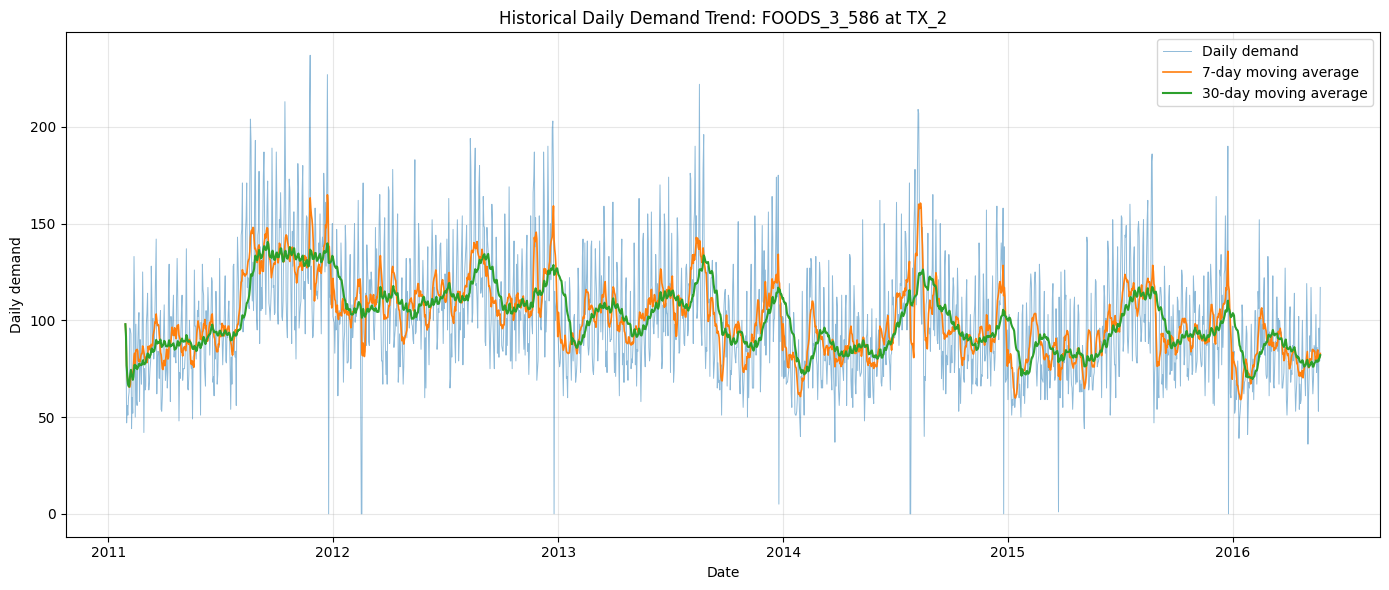

Historical demand trend figure saved to:
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/figures/historical_daily_demand_trend_FOODS_3_586_TX_2.png

Demand range:
Minimum demand: 0
Maximum demand: 237

Moving average variables created:
['demand_7day_ma', 'demand_30day_ma']


In [ ]:
# Plot historical daily demand trend for the selected item-store combination

# Create moving average variables
daily_demand["demand_7day_ma"] = daily_demand["demand"].rolling(window=7, min_periods=1).mean()
daily_demand["demand_30day_ma"] = daily_demand["demand"].rolling(window=30, min_periods=1).mean()

# Create the historical demand trend plot
plt.figure(figsize=(14, 6))

plt.plot(
    daily_demand["date"],
    daily_demand["demand"],
    linewidth=0.7,
    alpha=0.5,
    label="Daily demand"
)

plt.plot(
    daily_demand["date"],
    daily_demand["demand_7day_ma"],
    linewidth=1.2,
    label="7-day moving average"
)

plt.plot(
    daily_demand["date"],
    daily_demand["demand_30day_ma"],
    linewidth=1.5,
    label="30-day moving average"
)

plt.title("Historical Daily Demand Trend: FOODS_3_586 at TX_2")
plt.xlabel("Date")
plt.ylabel("Daily demand")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save the figure
figure_path = figures_dir / "historical_daily_demand_trend_FOODS_3_586_TX_2.png"
plt.savefig(figure_path, dpi=300)

plt.show()

print("Historical demand trend figure saved to:")
print(figure_path)

print("\nDemand range:")
print("Minimum demand:", daily_demand["demand"].min())
print("Maximum demand:", daily_demand["demand"].max())

print("\nMoving average variables created:")
print(["demand_7day_ma", "demand_30day_ma"])

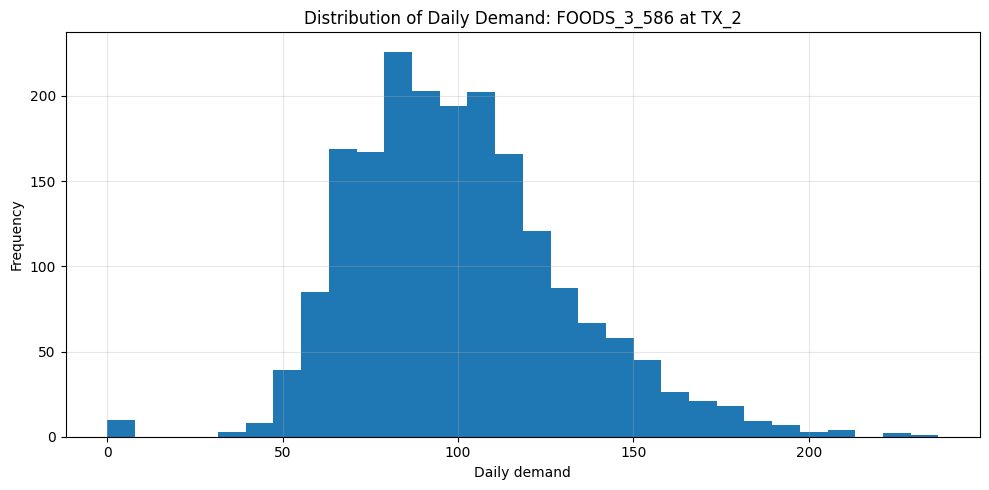

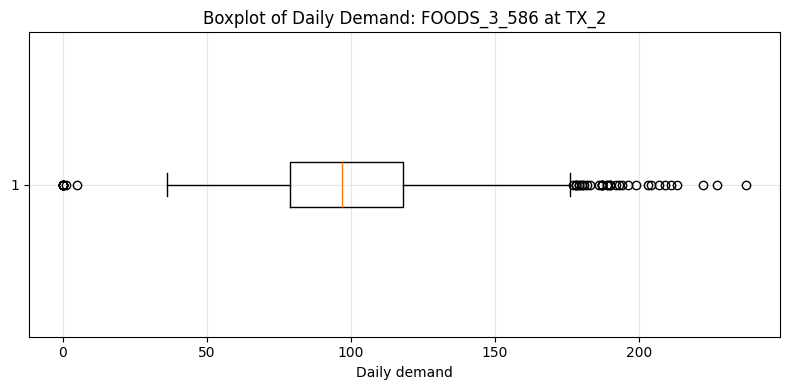

Demand distribution analysis completed.

Demand summary:


,demand
count,1941.000000
mean,100.525502
std,30.824629
min,0.000000
25%,79.000000
50%,97.000000
75%,118.000000
max,237.000000



IQR outlier thresholds:
Q1: 79.0
Q3: 118.0
IQR: 39.0
Lower bound: 20.5
Upper bound: 176.5

Number of potential outlier days:
45

Potential outlier days:


,date,demand,weekday,month,year,sell_price
203,2011-08-20,204,Saturday,8,2011,1.48
204,2011-08-21,192,Sunday,8,2011,1.48
211,2011-08-28,193,Sunday,8,2011,1.48
217,2011-09-03,177,Saturday,9,2011,1.48
225,2011-09-11,187,Sunday,9,2011,1.48
238,2011-09-24,189,Saturday,9,2011,1.48
245,2011-10-01,187,Saturday,10,2011,1.48
259,2011-10-15,213,Saturday,10,2011,1.48
280,2011-11-05,181,Saturday,11,2011,1.48
288,2011-11-13,180,Sunday,11,2011,1.48



Figures saved to:
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/figures/daily_demand_distribution_FOODS_3_586_TX_2.png
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/figures/daily_demand_boxplot_FOODS_3_586_TX_2.png


In [ ]:
# Step 08: Analyze demand distribution and potential outliers

# Calculate demand distribution summary
demand_summary = daily_demand["demand"].describe()

# Calculate IQR-based outlier threshold
q1 = daily_demand["demand"].quantile(0.25)
q3 = daily_demand["demand"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_days = daily_demand[
    (daily_demand["demand"] < lower_bound) |
    (daily_demand["demand"] > upper_bound)
]

# Plot histogram
plt.figure(figsize=(10, 5))
plt.hist(daily_demand["demand"], bins=30)
plt.title("Distribution of Daily Demand: FOODS_3_586 at TX_2")
plt.xlabel("Daily demand")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.tight_layout()

histogram_path = figures_dir / "daily_demand_distribution_FOODS_3_586_TX_2.png"
plt.savefig(histogram_path, dpi=300)
plt.show()

# Plot boxplot
plt.figure(figsize=(8, 4))
plt.boxplot(daily_demand["demand"], vert=False)
plt.title("Boxplot of Daily Demand: FOODS_3_586 at TX_2")
plt.xlabel("Daily demand")
plt.grid(True, alpha=0.3)
plt.tight_layout()

boxplot_path = figures_dir / "daily_demand_boxplot_FOODS_3_586_TX_2.png"
plt.savefig(boxplot_path, dpi=300)
plt.show()

print("Demand distribution analysis completed.")

print("\nDemand summary:")
display(demand_summary.to_frame(name="demand"))

print("\nIQR outlier thresholds:")
print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

print("\nNumber of potential outlier days:")
print(len(outlier_days))

print("\nPotential outlier days:")
display(outlier_days[["date", "demand", "weekday", "month", "year", "sell_price"]].head(20))

print("\nFigures saved to:")
print(histogram_path)
print(boxplot_path)

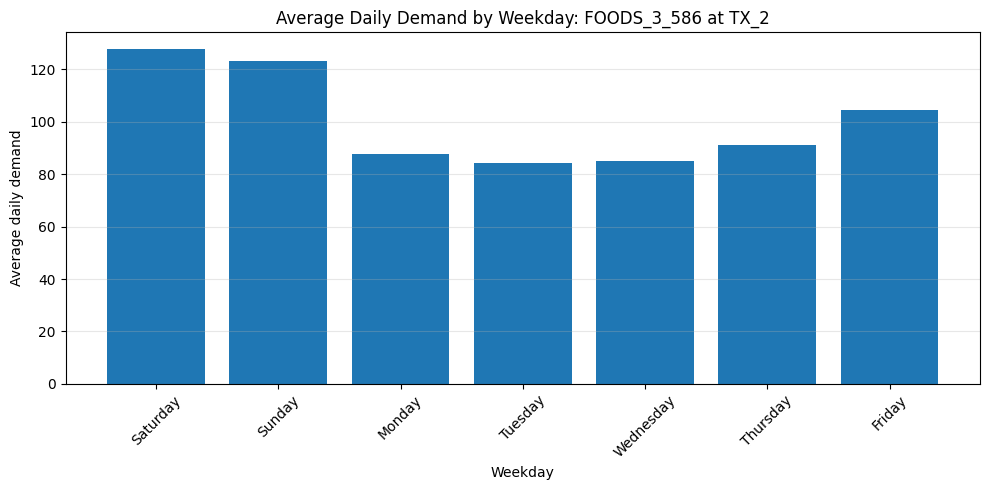

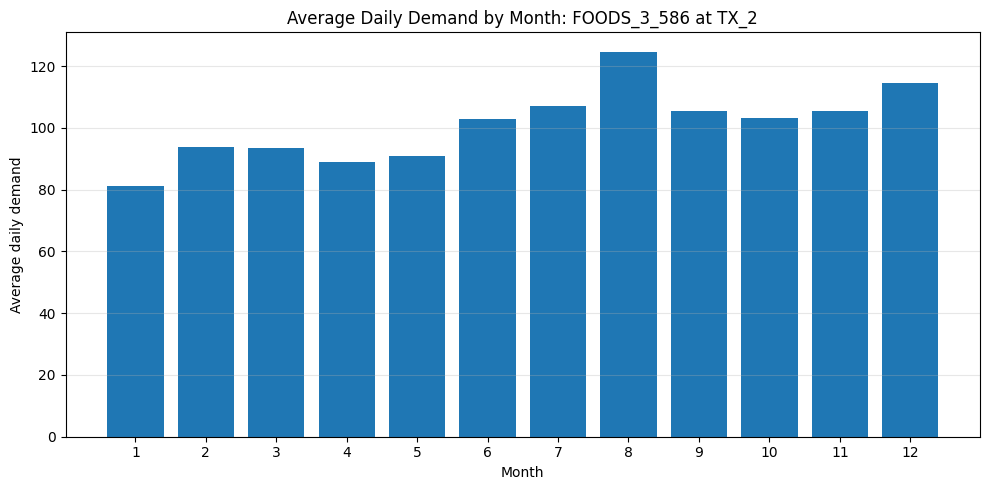

Step 09 completed: Weekday and monthly demand pattern analysis.

Weekday demand summary:


,wday,weekday,number_of_days,mean_demand,median_demand,std_demand,min_demand,max_demand
0,1,Saturday,278,127.715827,125.0,29.138196,0,213
1,2,Sunday,278,123.133094,120.0,29.351356,0,222
2,3,Monday,277,87.848375,84.0,23.347534,36,174
3,4,Tuesday,277,84.090253,82.0,21.355407,0,175
4,5,Wednesday,277,84.902527,81.0,21.480895,5,166
5,6,Thursday,277,91.216606,89.0,25.594030,0,211
6,7,Friday,277,104.592058,102.0,28.352651,0,237



Monthly demand summary:


,month,number_of_days,mean_demand,median_demand,std_demand,min_demand,max_demand
0,1,158,81.246835,79.0,22.476792,39,149
1,2,170,93.970588,91.0,27.654980,0,171
2,3,186,93.548387,89.5,26.914486,1,169
3,4,180,89.005556,84.0,23.529014,48,178
4,5,177,90.983051,87.0,25.029182,36,183
5,6,150,102.780000,101.0,24.924280,51,174
6,7,155,107.038710,105.0,27.513606,0,171
7,8,155,124.748387,118.0,35.032933,40,222
8,9,150,105.646667,104.5,30.281706,51,189
9,10,155,103.290323,100.0,29.286531,53,213



Check total number of days:
Weekday total days: 1941
Monthly total days: 1941

Figures saved to:
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/figures/average_demand_by_weekday_FOODS_3_586_TX_2.png
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/figures/average_demand_by_weekday_FOODS_3_586_TX_2.pdf
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/figures/average_demand_by_month_FOODS_3_586_TX_2.png
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/figures/average_demand_by_month_FOODS_3_586_TX_2.pdf


In [ ]:
# Step 09: Analyze weekday and monthly demand patterns

# Summarize demand by weekday
weekday_demand_summary = daily_demand.groupby(
    ["wday", "weekday"], as_index=False
).agg(
    number_of_days=("demand", "count"),
    mean_demand=("demand", "mean"),
    median_demand=("demand", "median"),
    std_demand=("demand", "std"),
    min_demand=("demand", "min"),
    max_demand=("demand", "max")
).sort_values("wday")

# Summarize demand by month
monthly_demand_summary = daily_demand.groupby(
    "month", as_index=False
).agg(
    number_of_days=("demand", "count"),
    mean_demand=("demand", "mean"),
    median_demand=("demand", "median"),
    std_demand=("demand", "std"),
    min_demand=("demand", "min"),
    max_demand=("demand", "max")
).sort_values("month")


# ============================================================
# Plot 1: Average demand by weekday
# ============================================================

plt.figure(figsize=(10, 5))

plt.bar(
    weekday_demand_summary["weekday"],
    weekday_demand_summary["mean_demand"]
)

plt.title("Average Daily Demand by Weekday: FOODS_3_586 at TX_2")
plt.xlabel("Weekday")
plt.ylabel("Average daily demand")
plt.xticks(rotation=45)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()

weekday_png_path = figures_dir / "average_demand_by_weekday_FOODS_3_586_TX_2.png"
weekday_pdf_path = figures_dir / "average_demand_by_weekday_FOODS_3_586_TX_2.pdf"

plt.savefig(weekday_png_path, dpi=300, bbox_inches="tight")
plt.savefig(weekday_pdf_path, bbox_inches="tight")

plt.show()


# ============================================================
# Plot 2: Average demand by month
# ============================================================

plt.figure(figsize=(10, 5))

plt.bar(
    monthly_demand_summary["month"],
    monthly_demand_summary["mean_demand"]
)

plt.title("Average Daily Demand by Month: FOODS_3_586 at TX_2")
plt.xlabel("Month")
plt.ylabel("Average daily demand")
plt.xticks(monthly_demand_summary["month"])
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()

monthly_png_path = figures_dir / "average_demand_by_month_FOODS_3_586_TX_2.png"
monthly_pdf_path = figures_dir / "average_demand_by_month_FOODS_3_586_TX_2.pdf"

plt.savefig(monthly_png_path, dpi=300, bbox_inches="tight")
plt.savefig(monthly_pdf_path, bbox_inches="tight")

plt.show()


# ============================================================
# Print summary outputs
# ============================================================

print("Step 09 completed: Weekday and monthly demand pattern analysis.")

print("\nWeekday demand summary:")
display(weekday_demand_summary)

print("\nMonthly demand summary:")
display(monthly_demand_summary)

print("\nCheck total number of days:")
print("Weekday total days:", weekday_demand_summary["number_of_days"].sum())
print("Monthly total days:", monthly_demand_summary["number_of_days"].sum())

print("\nFigures saved to:")
print(weekday_png_path)
print(weekday_pdf_path)
print(monthly_png_path)
print(monthly_pdf_path)

In [ ]:
# Step 10: Create tables folder and save EDA summary tables

# Define the tables directory
tables_dir = project_dir / "outputs" / "tables"
tables_dir.mkdir(parents=True, exist_ok=True)

# Define output table paths
weekday_summary_path = tables_dir / "weekday_demand_summary_FOODS_3_586_TX_2.csv"
monthly_summary_path = tables_dir / "monthly_demand_summary_FOODS_3_586_TX_2.csv"

# Save summary tables
weekday_demand_summary.to_csv(weekday_summary_path, index=False)
monthly_demand_summary.to_csv(monthly_summary_path, index=False)

print("Step 10 completed: EDA summary tables saved.")

print("\nTables saved to:")
print(weekday_summary_path)
print(monthly_summary_path)

print("\nCheck table shapes:")
print("Weekday demand summary shape:", weekday_demand_summary.shape)
print("Monthly demand summary shape:", monthly_demand_summary.shape)

Step 10 completed: EDA summary tables saved.

Tables saved to:
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/tables/weekday_demand_summary_FOODS_3_586_TX_2.csv
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/tables/monthly_demand_summary_FOODS_3_586_TX_2.csv

Check table shapes:
Weekday demand summary shape: (7, 8)
Monthly demand summary shape: (12, 7)


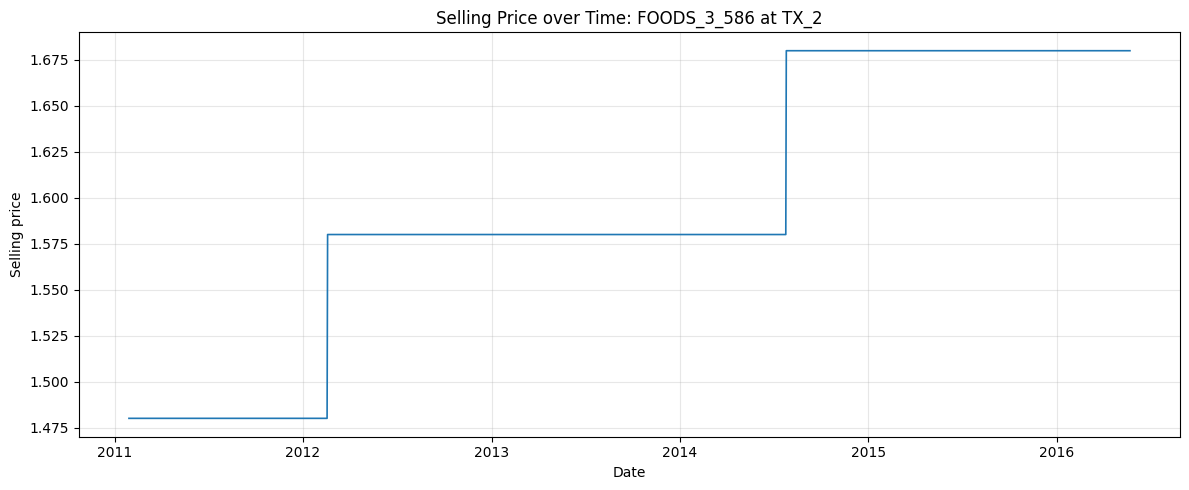

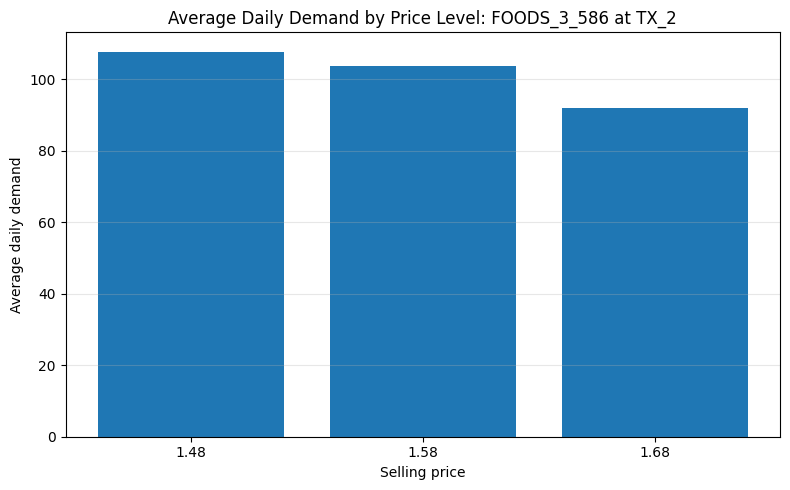

Step 11 completed: Price pattern and demand-by-price analysis.

Price-demand summary:


,sell_price,number_of_days,mean_demand,median_demand,std_demand,min_demand,max_demand
0,1.48,385,107.698701,103.0,34.854797,0,237
1,1.58,889,103.776153,101.0,29.534002,0,222
2,1.68,667,92.052474,87.0,28.080407,0,209



Number of unique price levels:
3

Price range:
Minimum price: 1.48
Maximum price: 1.68

Check total number of days:
Price summary total days: 1941

Table saved to:
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/tables/price_demand_summary_FOODS_3_586_TX_2.csv

Figures saved to:
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/figures/price_trend_FOODS_3_586_TX_2.png
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/figures/price_trend_FOODS_3_586_TX_2.pdf
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/figures/average_demand_by_price_FOODS_3_586_TX_2.png
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/figures/average_demand_by_price_FOODS_3_586_TX_2.pdf


In [ ]:
# Step 11: Analyze price pattern and demand by price level

# Ensure the tables directory exists
tables_dir = project_dir / "outputs" / "tables"
tables_dir.mkdir(parents=True, exist_ok=True)

# Summarize demand by selling price
price_demand_summary = daily_demand.groupby(
    "sell_price", as_index=False
).agg(
    number_of_days=("demand", "count"),
    mean_demand=("demand", "mean"),
    median_demand=("demand", "median"),
    std_demand=("demand", "std"),
    min_demand=("demand", "min"),
    max_demand=("demand", "max")
).sort_values("sell_price")

# Save the price-demand summary table
price_summary_path = tables_dir / "price_demand_summary_FOODS_3_586_TX_2.csv"
price_demand_summary.to_csv(price_summary_path, index=False)


# ============================================================
# Plot 1: Selling price over time
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    daily_demand["date"],
    daily_demand["sell_price"],
    linewidth=1.2
)

plt.title("Selling Price over Time: FOODS_3_586 at TX_2")
plt.xlabel("Date")
plt.ylabel("Selling price")
plt.grid(True, alpha=0.3)
plt.tight_layout()

price_trend_png_path = figures_dir / "price_trend_FOODS_3_586_TX_2.png"
price_trend_pdf_path = figures_dir / "price_trend_FOODS_3_586_TX_2.pdf"

plt.savefig(price_trend_png_path, dpi=300, bbox_inches="tight")
plt.savefig(price_trend_pdf_path, bbox_inches="tight")

plt.show()


# ============================================================
# Plot 2: Average demand by price level
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    price_demand_summary["sell_price"].astype(str),
    price_demand_summary["mean_demand"]
)

plt.title("Average Daily Demand by Price Level: FOODS_3_586 at TX_2")
plt.xlabel("Selling price")
plt.ylabel("Average daily demand")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()

demand_by_price_png_path = figures_dir / "average_demand_by_price_FOODS_3_586_TX_2.png"
demand_by_price_pdf_path = figures_dir / "average_demand_by_price_FOODS_3_586_TX_2.pdf"

plt.savefig(demand_by_price_png_path, dpi=300, bbox_inches="tight")
plt.savefig(demand_by_price_pdf_path, bbox_inches="tight")

plt.show()


# ============================================================
# Print summary outputs
# ============================================================

print("Step 11 completed: Price pattern and demand-by-price analysis.")

print("\nPrice-demand summary:")
display(price_demand_summary)

print("\nNumber of unique price levels:")
print(daily_demand["sell_price"].nunique())

print("\nPrice range:")
print("Minimum price:", daily_demand["sell_price"].min())
print("Maximum price:", daily_demand["sell_price"].max())

print("\nCheck total number of days:")
print("Price summary total days:", price_demand_summary["number_of_days"].sum())

print("\nTable saved to:")
print(price_summary_path)

print("\nFigures saved to:")
print(price_trend_png_path)
print(price_trend_pdf_path)
print(demand_by_price_png_path)
print(demand_by_price_pdf_path)

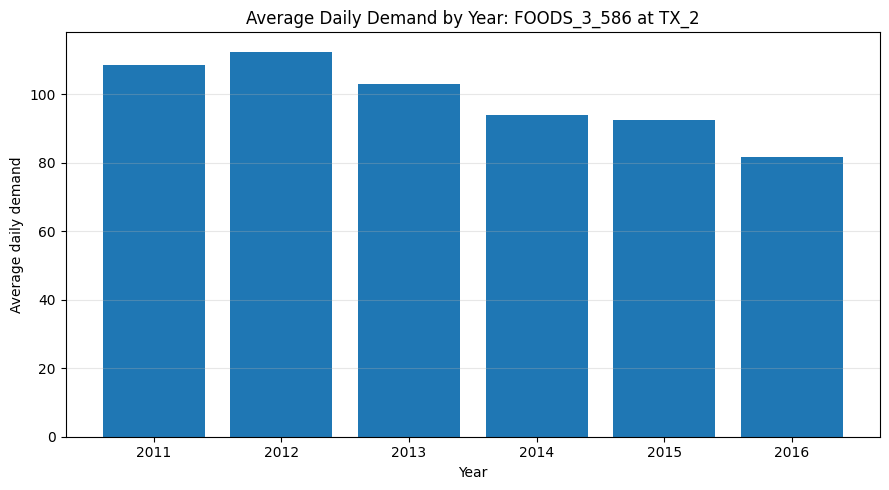

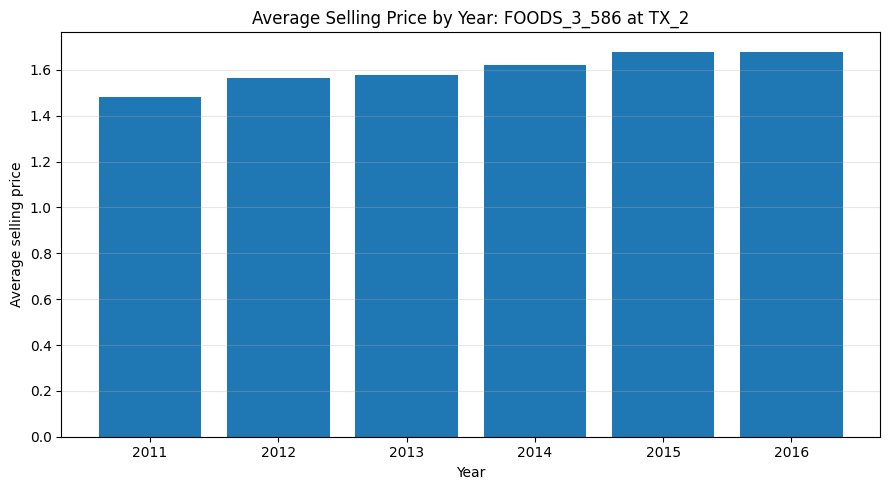

Step 12 completed: Yearly demand and price pattern analysis.

Yearly demand and price summary:


,year,number_of_days,mean_demand,median_demand,std_demand,min_demand,max_demand,mean_price,min_price,max_price
0,2011,337,108.528190,104.0,35.275952,0,237,1.480000,1.48,1.48
1,2012,366,112.519126,108.0,29.708140,0,203,1.566885,1.48,1.58
2,2013,365,103.076712,99.0,28.397679,5,222,1.580000,1.58,1.58
3,2014,365,93.849315,90.0,29.361741,0,209,1.623562,1.58,1.68
4,2015,365,92.632877,89.0,27.242642,0,190,1.680000,1.68,1.68
5,2016,143,81.643357,80.0,20.376528,36,152,1.680000,1.68,1.68



Check total number of days:
Yearly total days: 1941

Table saved to:
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/tables/yearly_demand_price_summary_FOODS_3_586_TX_2.csv

Figures saved to:
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/figures/average_demand_by_year_FOODS_3_586_TX_2.png
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/figures/average_demand_by_year_FOODS_3_586_TX_2.pdf
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/figures/average_price_by_year_FOODS_3_586_TX_2.png
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/figures/average_price_by_year_FOODS_3_586_TX_2.pdf


In [ ]:
# Step 12: Analyze yearly demand and price patterns

# Summarize demand and price by year
yearly_demand_summary = daily_demand.groupby(
    "year", as_index=False
).agg(
    number_of_days=("demand", "count"),
    mean_demand=("demand", "mean"),
    median_demand=("demand", "median"),
    std_demand=("demand", "std"),
    min_demand=("demand", "min"),
    max_demand=("demand", "max"),
    mean_price=("sell_price", "mean"),
    min_price=("sell_price", "min"),
    max_price=("sell_price", "max")
).sort_values("year")

# Save yearly summary table
yearly_summary_path = tables_dir / "yearly_demand_price_summary_FOODS_3_586_TX_2.csv"
yearly_demand_summary.to_csv(yearly_summary_path, index=False)


# ============================================================
# Plot 1: Average demand by year
# ============================================================

plt.figure(figsize=(9, 5))

plt.bar(
    yearly_demand_summary["year"].astype(str),
    yearly_demand_summary["mean_demand"]
)

plt.title("Average Daily Demand by Year: FOODS_3_586 at TX_2")
plt.xlabel("Year")
plt.ylabel("Average daily demand")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()

yearly_demand_png_path = figures_dir / "average_demand_by_year_FOODS_3_586_TX_2.png"
yearly_demand_pdf_path = figures_dir / "average_demand_by_year_FOODS_3_586_TX_2.pdf"

plt.savefig(yearly_demand_png_path, dpi=300, bbox_inches="tight")
plt.savefig(yearly_demand_pdf_path, bbox_inches="tight")

plt.show()


# ============================================================
# Plot 2: Average selling price by year
# ============================================================

plt.figure(figsize=(9, 5))

plt.bar(
    yearly_demand_summary["year"].astype(str),
    yearly_demand_summary["mean_price"]
)

plt.title("Average Selling Price by Year: FOODS_3_586 at TX_2")
plt.xlabel("Year")
plt.ylabel("Average selling price")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()

yearly_price_png_path = figures_dir / "average_price_by_year_FOODS_3_586_TX_2.png"
yearly_price_pdf_path = figures_dir / "average_price_by_year_FOODS_3_586_TX_2.pdf"

plt.savefig(yearly_price_png_path, dpi=300, bbox_inches="tight")
plt.savefig(yearly_price_pdf_path, bbox_inches="tight")

plt.show()


# ============================================================
# Print summary outputs
# ============================================================

print("Step 12 completed: Yearly demand and price pattern analysis.")

print("\nYearly demand and price summary:")
display(yearly_demand_summary)

print("\nCheck total number of days:")
print("Yearly total days:", yearly_demand_summary["number_of_days"].sum())

print("\nTable saved to:")
print(yearly_summary_path)

print("\nFigures saved to:")
print(yearly_demand_png_path)
print(yearly_demand_pdf_path)
print(yearly_price_png_path)
print(yearly_price_pdf_path)

In [ ]:
# Step 13: Create a compact EDA findings summary

# Identify key demand statistics
total_days = len(daily_demand)
mean_demand = daily_demand["demand"].mean()
median_demand = daily_demand["demand"].median()
std_demand = daily_demand["demand"].std()
min_demand = daily_demand["demand"].min()
max_demand = daily_demand["demand"].max()
zero_demand_days = (daily_demand["demand"] == 0).sum()
zero_demand_rate = zero_demand_days / total_days

# Identify highest and lowest average-demand weekdays
highest_weekday = weekday_demand_summary.loc[
    weekday_demand_summary["mean_demand"].idxmax()
]

lowest_weekday = weekday_demand_summary.loc[
    weekday_demand_summary["mean_demand"].idxmin()
]

# Identify highest and lowest average-demand months
highest_month = monthly_demand_summary.loc[
    monthly_demand_summary["mean_demand"].idxmax()
]

lowest_month = monthly_demand_summary.loc[
    monthly_demand_summary["mean_demand"].idxmin()
]

# Identify price and yearly trend summaries
lowest_price_row = price_demand_summary.loc[
    price_demand_summary["sell_price"].idxmin()
]

highest_price_row = price_demand_summary.loc[
    price_demand_summary["sell_price"].idxmax()
]

highest_year = yearly_demand_summary.loc[
    yearly_demand_summary["mean_demand"].idxmax()
]

lowest_year = yearly_demand_summary.loc[
    yearly_demand_summary["mean_demand"].idxmin()
]

# Create a compact findings table
eda_findings = pd.DataFrame({
    "finding": [
        "Total number of daily observations",
        "Average daily demand",
        "Median daily demand",
        "Demand standard deviation",
        "Minimum daily demand",
        "Maximum daily demand",
        "Zero-demand days",
        "Zero-demand rate",
        "Highest average-demand weekday",
        "Lowest average-demand weekday",
        "Highest average-demand month",
        "Lowest average-demand month",
        "Average demand at lowest price level",
        "Average demand at highest price level",
        "Highest average-demand year",
        "Lowest average-demand year"
    ],
    "value": [
        total_days,
        round(mean_demand, 2),
        round(median_demand, 2),
        round(std_demand, 2),
        min_demand,
        max_demand,
        zero_demand_days,
        round(zero_demand_rate, 4),
        f"{highest_weekday['weekday']} ({highest_weekday['mean_demand']:.2f})",
        f"{lowest_weekday['weekday']} ({lowest_weekday['mean_demand']:.2f})",
        f"{int(highest_month['month'])} ({highest_month['mean_demand']:.2f})",
        f"{int(lowest_month['month'])} ({lowest_month['mean_demand']:.2f})",
        f"{lowest_price_row['sell_price']:.2f} ({lowest_price_row['mean_demand']:.2f})",
        f"{highest_price_row['sell_price']:.2f} ({highest_price_row['mean_demand']:.2f})",
        f"{int(highest_year['year'])} ({highest_year['mean_demand']:.2f})",
        f"{int(lowest_year['year'])} ({lowest_year['mean_demand']:.2f})"
    ]
})

# Save the EDA findings table
eda_findings_path = tables_dir / "eda_key_findings_FOODS_3_586_TX_2.csv"
eda_findings.to_csv(eda_findings_path, index=False)

print("Step 13 completed: Compact EDA findings summary created.")

print("\nEDA key findings:")
display(eda_findings)

print("\nTable saved to:")
print(eda_findings_path)

Step 13 completed: Compact EDA findings summary created.

EDA key findings:


,finding,value
0,Total number of daily observations,1941
1,Average daily demand,100.53
2,Median daily demand,97.0
3,Demand standard deviation,30.82
4,Minimum daily demand,0
5,Maximum daily demand,237
6,Zero-demand days,8
7,Zero-demand rate,0.0041
8,Highest average-demand weekday,Saturday (127.72)
9,Lowest average-demand weekday,Tuesday (84.09)



Table saved to:
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/tables/eda_key_findings_FOODS_3_586_TX_2.csv
